# Homework - Project

Activate virtual env: source .venv/bin/activate

## Step 1 - Import required libraries

In [1]:
# Import required libraries.
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import types

## Step 2 - Create a Spark session

In [2]:
# Create a Spark session.
spark = SparkSession.builder \
    .master("local[*]") \
    .appName('homework') \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/06 09:44:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/06 09:44:56 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/06 09:44:56 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/06 09:44:56 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


## Step 3 - Checking Spark version

In [ ]:
spark.version

'4.1.1'

## Step 4 - Download and inspect local files and raw data

In [36]:
!mkdir -p ./data && if [ ! -f ./data/yellow_tripdata_2025-11.parquet ]; then wget -P ./data https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-11.parquet; fi

In [43]:
# Inspect local files and raw data.
!ls -lh ./data/yellow_tripdata_2025-11.parquet

-rw-r--r--@ 1 rgctechfi  staff    68M Dec 19 16:51 ./data/yellow_tripdata_2025-11.parquet


## Step 5 - Load data into a Spark DataFrame

In [54]:
# Load data into a Spark DataFrame.
df = spark.read \
    .option("header", "true") \
    .parquet('./data/yellow_tripdata_2025-11.parquet')

df = df.repartition(4)

## Step 7 - Load data into a Spark DataFrame

In [55]:
# Load data into a Spark DataFrame.
df = spark.read.parquet('./data/yellow_tripdata_2025-11.parquet')
df.printSchema()
df.show(5)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+------

# Partitioned

In [56]:
df.repartition(4).write.parquet('data/partitioned/yellow_2025_11_repartitioned')


AnalysisException: [PATH_ALREADY_EXISTS] Path file:/Users/rgctechfi/Projects/spark/project/data/partitioned/yellow_2025_11_repartitioned already exists. Set mode as "overwrite" to overwrite the existing path. SQLSTATE: 42K04

- _SUCCESS file (which indicates that the job finished successfully).

- 4 files starting with part-0000x... and ending with .parquet.

Size : 25 MiB for each file

In [58]:
ls -lah ./data/partitioned/yellow_2025_11_repartitioned #h for displaying size but not in byte

total 207368
drwxr-xr-x@ 12 rgctechfi  staff   384B Mar  6 14:22 ./
drwxr-xr-x@  3 rgctechfi  staff    96B Mar  6 14:22 ../
-rw-r--r--@  1 rgctechfi  staff     8B Mar  6 14:22 ._SUCCESS.crc
-rw-r--r--@  1 rgctechfi  staff   195K Mar  6 14:22 .part-00000-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet.crc
-rw-r--r--@  1 rgctechfi  staff   195K Mar  6 14:22 .part-00001-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet.crc
-rw-r--r--@  1 rgctechfi  staff   195K Mar  6 14:22 .part-00002-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet.crc
-rw-r--r--@  1 rgctechfi  staff   195K Mar  6 14:22 .part-00003-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet.crc
-rw-r--r--@  1 rgctechfi  staff     0B Mar  6 14:22 _SUCCESS
-rw-r--r--@  1 rgctechfi  staff    24M Mar  6 14:22 part-00000-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet
-rw-r--r--@  1 rgctechfi  staff    24M Mar  6 14:22 part-00001-fc2b83bd-e3f3-4ab4-b180-a888f1dee692-c000.snappy.parquet
-rw-r--r-

## Step 8 - Import required libraries

In [59]:
# Import required libraries.
from pyspark.sql import functions as F

## Step 10 - Register a temporary SQL view

In [60]:
# Register a temporary SQL view.
df.registerTempTable('yellow_2025_11')

/Users/rgctechfi/Projects/spark/.venv/lib/python3.13/site-packages/pyspark/sql/classic/dataframe.py:178: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


## Step 11 - Run a Spark SQL query - counting records

**Q3**: How many taxi trips were there on February 15?

In [61]:
# Run a Spark SQL query.
spark.sql("""
SELECT
    COUNT(1)
FROM 
    yellow_2025_11
WHERE
    to_date(tpep_pickup_datetime) = '2025-11-15';
""").show()

+--------+
|count(1)|
+--------+
|  162604|
+--------+



In [62]:
df \
    .withColumn("pickup_date", F.to_date("tpep_pickup_datetime")) \
    .groupBy("pickup_date") \
    .count() \
    .filter(F.col("pickup_date") == F.lit("2025-11-15")) \
    .show()


+-----------+------+
|pickup_date| count|
+-----------+------+
| 2025-11-15|162604|
+-----------+------+



## Q4: Longest trip for each day

Q4.1 spark sql version

In [ ]:
spark.sql("""
SELECT
  ROUND(
    MAX((unix_timestamp(tpep_dropoff_datetime) - unix_timestamp(tpep_pickup_datetime)) / 3600.0),
    1
  ) AS longest_trip_hours
FROM yellow_2025_11
WHERE tpep_dropoff_datetime >= tpep_pickup_datetime
""").show()

  #`tpep_pickup_datetime` and `tpep_dropoff_datetime` are TIMESTAMP columns.
  # Spark cannot always cast these safely to BIGINT (especially with timestamp_ntz),
  # so we convert each timestamp to Unix epoch seconds first.
  # Then: dropoff - pickup gives duration in seconds; / 3600.0 converts to hours.

+------------------+
|longest_trip_hours|
+------------------+
|              90.6|
+------------------+



Q4.2 Pyspark version

In [ ]:
(
    df
    # Keep only valid trips (dropoff after pickup).
    .where(F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime"))
    # Convert timestamps to Unix seconds, then compute trip duration in seconds.
    .select(
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime"))
        .alias("duration_seconds")
    )
    # Max duration -> hours.
    .agg(
        F.round(F.max("duration_seconds") / F.lit(3600.0), 1).alias("longest_trip_hours")
    )
    .show()
)


+------------------+
|longest_trip_hours|
+------------------+
|              90.6|
+------------------+



## Step 12 - Run Spark user interface

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("spark-dashboard-demo")
    .config("spark.executor.memory", "2g") # optimize performances
    .config("spark.ui.enabled", "true")
    .config("spark.ui.port", "4040")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

print("Spark UI:", spark.sparkContext.uiWebUrl)


Spark UI: http://macbookair.lan:4043


26/03/06 14:05:15 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


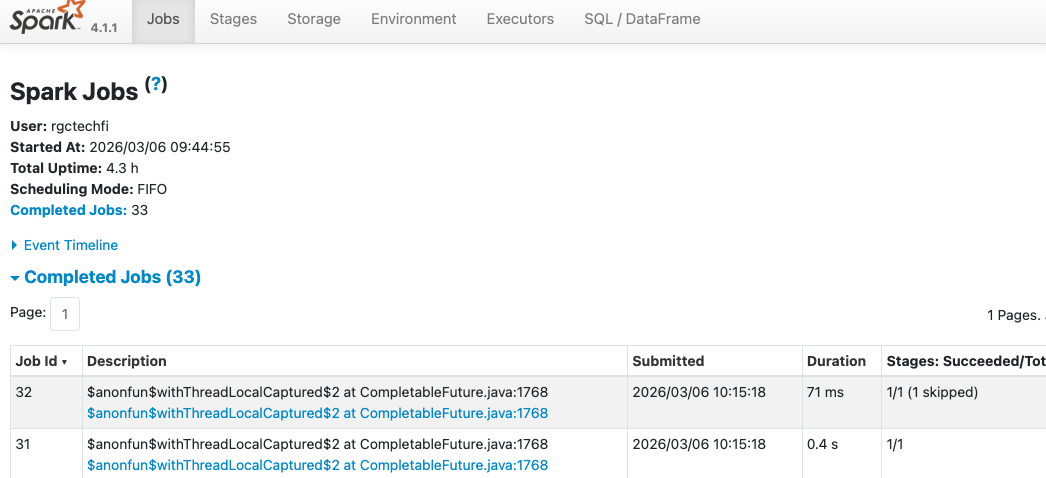

In [41]:
# Lance une action pour alimenter le dashboard
df = spark.read.parquet("./data/yellow_tripdata_2025-11.parquet")
df.groupBy("VendorID").count().show()


+--------+-------+
|VendorID|  count|
+--------+-------+
|       1| 821333|
|       7|  60043|
|       2|3295835|
|       6|   4233|
+--------+-------+



## Step 13 - Loading the zone lookup data into a temp view in Spark

In [53]:
!mkdir -p ./data && if [ ! -f ./data/taxi_zone_lookup.csv ]; then wget -P ./data https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv; fi

In [51]:
# Inspect local files and raw data.
!ls -lh ./data/taxi_zone_lookup.csv

-rw-r--r--@ 1 rgctechfi  staff    12K Feb 22  2024 ./data/taxi_zone_lookup.csv


In [63]:
# Load data into a Spark DataFrame.
df = spark.read \
    .option("header", "true") \
    .csv('./data/taxi_zone_lookup.csv')


In [64]:
# Register a temporary SQL view.
df.registerTempTable('taxi_zone_lookup')

### **Pyspark version**

In [67]:
y = spark.table("yellow_2025_11").alias("y")
z = (
    spark.table("taxi_zone_lookup")
    .withColumn("LocationID", F.col("LocationID").cast("int"))
    .alias("z")
)

(
    y.join(z, F.col("y.PULocationID") == F.col("z.LocationID"), "inner")
     .groupBy(F.col("z.Zone").alias("Zone"))
     .agg(F.count(F.lit(1)).alias("trips"))
     .orderBy(F.col("trips").asc(), F.col("Zone").asc())
     .limit(10)
     .show(truncate=False)
)


+---------------------------------------------+-----+
|Zone                                         |trips|
+---------------------------------------------+-----+
|Arden Heights                                |1    |
|Eltingville/Annadale/Prince's Bay            |1    |
|Governor's Island/Ellis Island/Liberty Island|1    |
|Port Richmond                                |3    |
|Great Kills                                  |4    |
|Green-Wood Cemetery                          |4    |
|Rikers Island                                |4    |
|Rossville/Woodrow                            |4    |
|Jamaica Bay                                  |5    |
|Westerleigh                                  |12   |
+---------------------------------------------+-----+



### **Spark SQL version**

In [65]:
spark.sql("""
SELECT z.Zone, COUNT(*) AS trips
FROM yellow_2025_11 y
JOIN taxi_zone_lookup z
  ON y.PULocationID = z.LocationID
GROUP BY z.Zone
ORDER BY trips ASC, z.Zone ASC
LIMIT 10
""").show(truncate=False)


+---------------------------------------------+-----+
|Zone                                         |trips|
+---------------------------------------------+-----+
|Arden Heights                                |1    |
|Eltingville/Annadale/Prince's Bay            |1    |
|Governor's Island/Ellis Island/Liberty Island|1    |
|Port Richmond                                |3    |
|Great Kills                                  |4    |
|Green-Wood Cemetery                          |4    |
|Rikers Island                                |4    |
|Rossville/Woodrow                            |4    |
|Jamaica Bay                                  |5    |
|Westerleigh                                  |12   |
+---------------------------------------------+-----+



The least frequent pickup location are :
Arden Heights
ou Governor's Island/Ellis Island/Liberty Island